In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 40

In [2]:
processed_dir = "../data/processed"

X_train = pd.read_csv(f"{processed_dir}/X_train.csv")
X_test = pd.read_csv(f"{processed_dir}/X_test.csv")
y_train = pd.read_csv(f"{processed_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_dir}/y_test.csv").squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train: (5861, 8) | Test: (1466, 8)
Train class balance:
 koi_disposition
0    0.62532
1    0.37468
Name: proportion, dtype: float64


In [3]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"DummyClassifier (most_frequent) accuracy: {dummy_acc:.4f}")

DummyClassifier (most_frequent) accuracy: 0.6255


In [4]:
log_reg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight="balanced"  # 63/46 so we have to balance it
)

log_reg.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",40
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring=metric)
    cv_scores[metric] = scores
    print(f"{metric:10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

accuracy  : 0.7830 (+/- 0.0120)
precision : 0.6573 (+/- 0.0143)
recall    : 0.8802 (+/- 0.0177)
f1        : 0.7525 (+/- 0.0125)
roc_auc   : 0.8785 (+/- 0.0084)


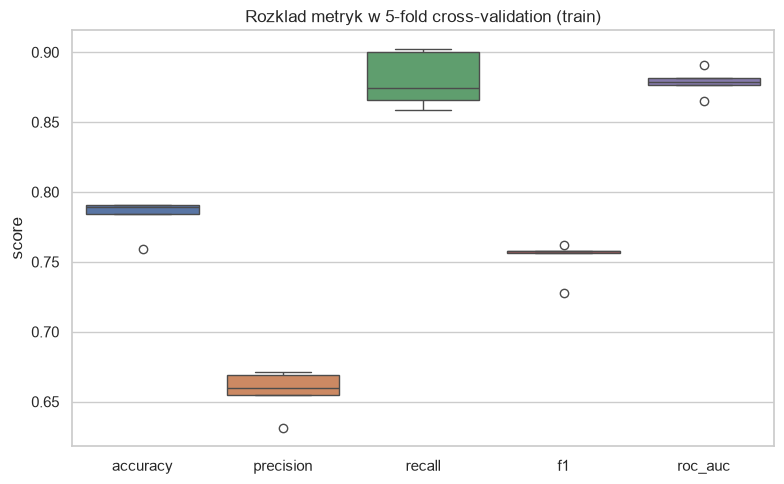

In [6]:
cv_df = pd.DataFrame(cv_scores)
cv_df.index = [f"fold_{i+1}" for i in range(len(cv_df))]

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df)
plt.title("Rozklad metryk w 5-fold cross-validation (train)")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [7]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

print(f"\nBaseline (dummy) accuracy: {dummy_acc:.4f}  ->  Log. reg. accuracy: {metrics['accuracy']:.4f}")

accuracy  : 0.7756
precision : 0.6455
recall    : 0.8889
f1        : 0.7479
roc_auc   : 0.8800

Baseline (dummy) accuracy: 0.6255  ->  Log. reg. accuracy: 0.7756


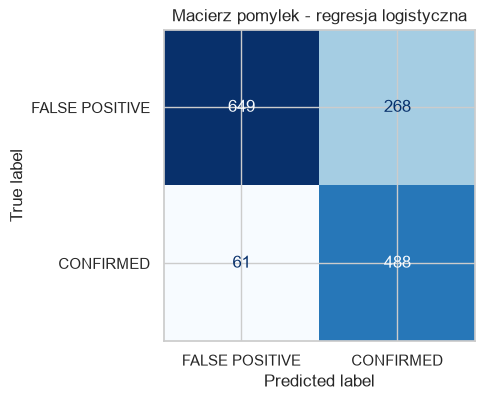

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FALSE POSITIVE", "CONFIRMED"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Macierz pomylek - regresja logistyczna")
plt.tight_layout()
plt.show()

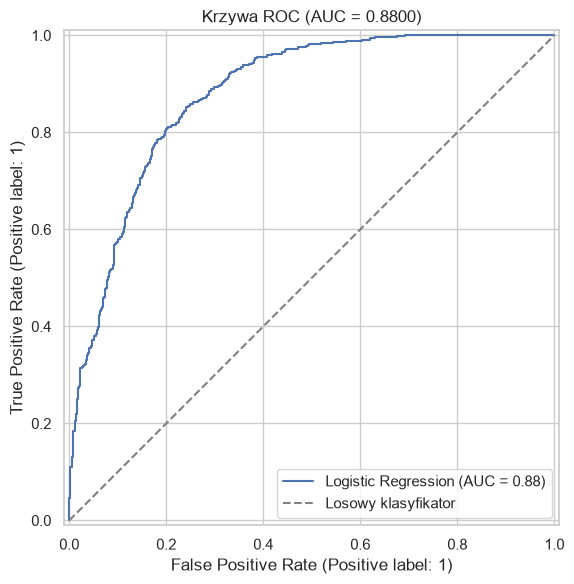

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Losowy klasyfikator")
ax.set_title(f"Krzywa ROC (AUC = {metrics['roc_auc']:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
5,koi_insol,-8.133361
4,koi_teq,6.962707
3,koi_prad,-2.623782
6,koi_model_snr,1.970057
2,koi_depth,-0.844384
1,koi_duration,-0.761992
7,koi_impact,-0.700292
0,koi_period,0.202770


C:\Users\kamil\AppData\Local\Temp\ipykernel_5624\3734919290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="coefficient", y="feature", palette=colors)


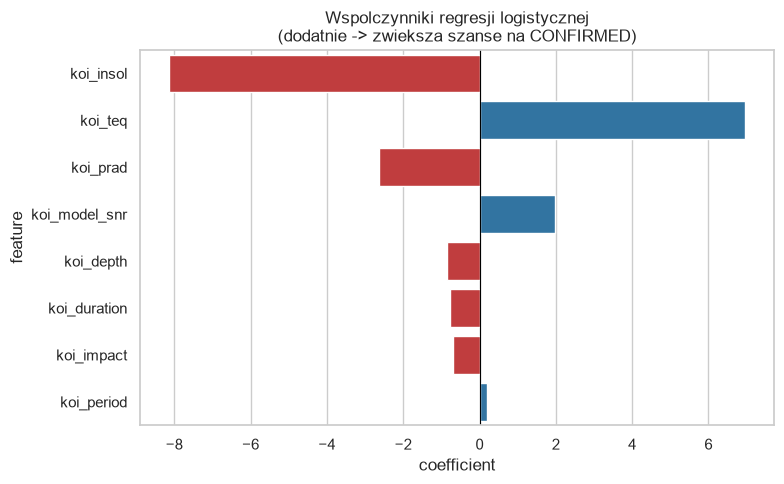

In [11]:
plt.figure(figsize=(8, 5))
colors = ["#d62728" if c < 0 else "#1f77b4" for c in coef_df["coefficient"]]
sns.barplot(data=coef_df, x="coefficient", y="feature", palette=colors)
plt.title("Coefficient of logistic regression \n(positive -> bigger chance for CONFIRMED)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [12]:
X_test_raw = pd.read_csv(f"{processed_dir}/X_test_raw.csv")

errors = X_test_raw.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors["y_proba"] = y_proba
errors["is_error"] = errors["y_true"] != errors["y_pred"]
errors["confidence"] = np.where(errors["y_pred"] == 1, errors["y_proba"], 1 - errors["y_proba"])

print(f"Liczba bledow: {errors['is_error'].sum()} / {len(errors)} ({errors['is_error'].mean()*100:.2f}%)")

worst_errors = errors[errors["is_error"]].sort_values("confidence", ascending=False)
worst_errors.head(10)

Liczba bledow: 329 / 1466 (22.44%)


,koi_period,koi_duration,koi_depth,koi_impact,koi_prad,koi_teq,koi_insol,koi_model_snr,y_true,y_pred,y_proba,is_error,confidence
253,13.616455,5.1750,376.1,1.1900,22.29,755.0,76.81,22.6,1,0,0.037317,True,0.962683
536,364.751562,13.0570,1481.5,0.8750,2.89,166.0,0.18,25.5,1,0,0.044466,True,0.955534
1119,3.850305,1.5337,158.0,0.2900,0.28,407.0,6.44,5.3,0,1,0.950649,True,0.950649
748,3.003880,3.2848,8538.0,0.3380,10.96,1438.0,1011.87,80.8,1,0,0.066007,True,0.933993
151,8.653119,1.2730,206.8,0.7010,0.85,493.0,13.95,8.9,0,1,0.932975,True,0.932975
260,18.925372,3.9835,640.9,0.8060,13.92,1171.0,443.58,41.0,1,0,0.072024,True,0.927976
1098,62.134919,8.7110,147.5,0.8270,6.71,925.0,172.96,10.6,1,0,0.073470,True,0.926530
1413,3.849372,2.6320,1298.6,0.9150,12.94,2034.0,4055.29,132.7,1,0,0.081694,True,0.918306
1327,81.871309,1.6060,98.2,0.1996,1.12,480.0,12.59,5.4,0,1,0.913048,True,0.913048
1080,23.934182,1.6070,228.1,0.0465,1.03,432.0,8.27,6.5,0,1,0.912508,True,0.912508


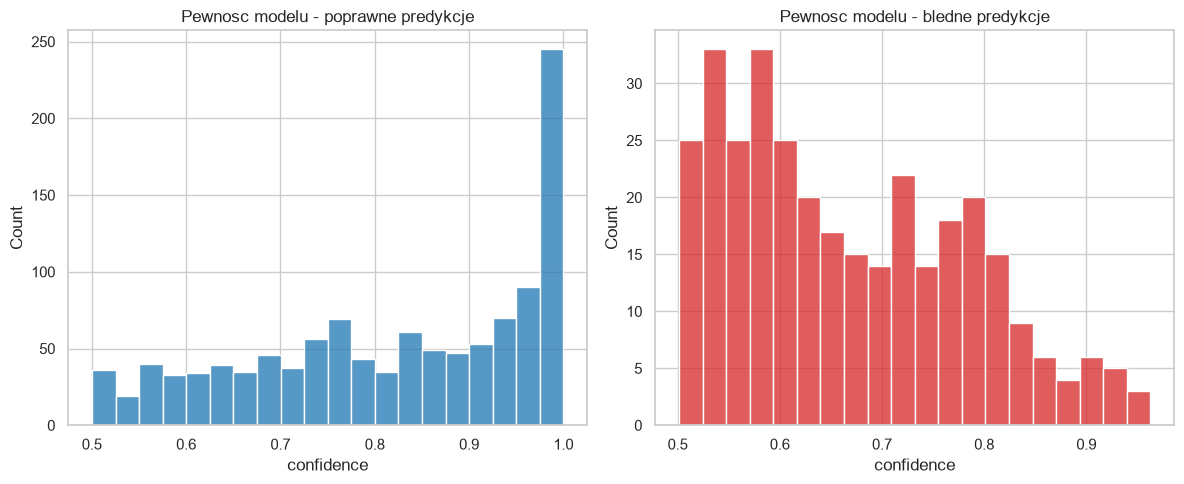

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(errors[~errors["is_error"]]["confidence"], ax=axes[0], color="#1f77b4", bins=20)
axes[0].set_title("Pewnosc modelu - poprawne predykcje")

sns.histplot(errors[errors["is_error"]]["confidence"], ax=axes[1], color="#d62728", bins=20)
axes[1].set_title("Pewnosc modelu - bledne predykcje")
plt.tight_layout()
plt.show()